---
title: "Efecto del *Inflation Targeting* sobre la inversión doméstica en México (2001): un enfoque de control sintético"
author:
  - name: "Patrick Maxime Destinobles Hernández, Bruno Sánchez Solís, José Manuel Vázquez Nicolás"
    affiliation: "Econometría II"
date: today
date-format: long
abstract: |
  México adoptó formalmente el régimen de *Inflation Targeting* (IT) en 2001. La teoría
  predice que el anclaje de expectativas debería reducir la incertidumbre macroeconómica
  y estimular la inversión, pero la evidencia empírica es heterogénea. Este trabajo estima
  el efecto causal de la adopción del IT sobre la formación bruta de capital fijo en México
  mediante el método de control sintético (Abadie et al., 2010), usando un panel del
  *World Development Indicators* (1984–2023) y un *donor pool* de economías no-OCDE.
  Frente a su contrafactual sintético, la inversión mexicana fue persistentemente menor
  tras la adopción del IT —del orden de −3.7 puntos del PIB en promedio—, en línea con la
  evidencia previa. Sin embargo, este trabajo argumenta que ese *gap* no puede atribuirse
  al IT. La inferencia por placebos (pseudo *p-value* ≈ 0.75) sitúa el efecto de México
  de lleno dentro de la distribución de los efectos placebo: tres de cada cuatro países
  que no adoptaron IT exhiben un *gap* igual o mayor. A ello se suma que el contrafactual
  sintético se compone mayoritariamente de exportadores de materias primas que se
  beneficiaron del súper-ciclo de *commodities* impulsado por China —el mismo choque que
  golpeó adversamente a la manufactura mexicana—, y que los supuestos de identificación
  del método (invarianza paramétrica, ausencia de interferencia) son frágiles en este
  contexto macroeconómico. La conclusión, por tanto, es deliberadamente cauta: los datos
  no permiten aislar un efecto causal del IT sobre la inversión, y el ejercicio resulta
  más informativo por los límites que revela del método que por la magnitud del *gap*.
keywords: [inflation targeting, control sintético, inversión, México, política monetaria]
jupyter: python3
---

::: {.callout-note}
## Cómo leer y reproducir este documento

**Trabajo Final — Econometría II.** Documento autocontenido y reproducible: todo el
análisis se ejecuta desde el panel congelado `data/panel_mccloud_mexico.csv` (datos del
*World Development Indicators* del Banco Mundial), **sin requerir conexión a internet**.

- **Obtención y limpieza de datos** (paso 00, previo): `script/00_datos.ipynb`.
- **Este documento** (paso 01: análisis, estimación y resultados): `01_analisis.qmd` → PDF y notebook.
- **Test de placebos** (único cálculo costoso, ~80 estimaciones): se precomputa con
  `script/_run_placebos.py` y se cachea en `out/`.

*Estructura:* 1 Introducción · 2 Marco teórico · 3 Datos · 4 Análisis descriptivo ·
5 Estrategia empírica · 6 Resultados · 7 Discusión · 8 Conclusiones.
:::

In [1]:
#| label: setup
#| include: false
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pysyncon import Dataprep, Synth
from IPython.display import Markdown, Image

plt.rcParams["figure.dpi"] = 150

# Introducción

México adoptó formalmente el régimen de *Inflation Targeting* (IT) en 2001, tras la crisis del peso de 1994–1995 y la reforma que otorgó autonomía constitucional al Banco de México (Ley de Autonomía de 1994). El IT busca anclar las expectativas de inflación mediante un objetivo explícito y público, reduciendo la incertidumbre macroeconómica. En teoría, esa reducción de incertidumbre debería estimular la inversión doméstica al disminuir la prima de riesgo y facilitar la planificación de largo plazo [@svensson2010].

Sin embargo, la evidencia empírica no es concluyente. @mccloud2022, usando el método de control sintético para 29 países, encuentra que en 21 de ellos **no hubo efecto significativo** del IT sobre la inversión, y que para México el efecto fue **negativo** —de hasta 7.48 puntos porcentuales del PIB en 2008—, atribuible a la credibilidad débil del banco central y a restricciones del sistema financiero doméstico. México aparece, además, como un caso recurrentemente difícil de modelar en la literatura de control sintético cuando el resultado de interés es la inflación.

**Pregunta de investigación.** ¿Cuál fue el efecto causal de la adopción del IT en 2001 sobre la inversión doméstica agregada en México?

Esta pregunta es relevante por tres razones. Primero, por su pertinencia para la política: México mantiene el IT como marco de política monetaria, y entender su efecto sobre la inversión —motor del crecimiento de largo plazo— es crucial para evaluar su desempeño. Segundo, porque México es un caso atípico: uno de los pocos países donde la literatura encuentra un efecto negativo significativo; si el IT desincentiva la inversión en economías con credibilidad débil, el diseño institucional importa tanto como el régimen mismo. Tercero, porque permite actualizar la evidencia: McCloud usa datos hasta 2017, mientras que nuestra ventana se extiende a 2023, cubriendo la pandemia de COVID-19 y permitiendo evaluar si el efecto persistió.

**Hipótesis de trabajo.** Contrastamos dos hipótesis:

- **H0 (efecto nulo):** la adopción del IT en 2001 no tuvo efecto sobre la formación bruta de capital fijo en México; la trayectoria observada es indistinguible de la de su contrafactual sintético.
- **H1 (alternativa):** el IT tuvo un efecto **negativo** sobre la inversión doméstica. El mecanismo propuesto por @mccloud2022 —credibilidad débil del banco central, expectativas de inflación persistentemente altas, restricciones del sistema financiero— implica que la inversión mexicana post-2001 es sistemáticamente menor que la de su contrafactual sin IT.

La direccionalidad negativa de H1 está motivada por la evidencia previa [@mccloud2022], por la dificultad del Banco de México para anclar expectativas en la primera década del régimen [@bambe2023] y por la baja profundidad del sistema financiero mexicano.

**Una advertencia metodológica, desde el inicio.** Anticipamos una tensión que estructura todo el documento: la adopción del IT en 2001 no ocurrió en el vacío. Coincidió casi exactamente con la aceleración del *China Shock* —el ingreso de China a la OMC en diciembre de 2001— y con un cambio de régimen en la formación de expectativas en México. En presencia de choques globales coincidentes y de un cambio estructural en el entorno de la unidad tratada, conviene preguntarse no solo *cuál fue el efecto del IT*, sino también **si el control sintético es la herramienta adecuada para responder esa pregunta** en este caso. Adelantamos que la respuesta es, en el mejor de los casos, ambigua: el método produce un *gap* negativo y grande, pero ese *gap* no es estadísticamente distinguible del ruido ni separable de los choques contemporáneos. Entender por qué es, en sí mismo, una lección sobre los límites de la evaluación de regímenes monetarios con métodos de control comparativo (Secciones 2.5 y 7).

**Contribución.** Este trabajo no replica mecánicamente a McCloud, sino que toma su estrategia de identificación como punto de partida para responder una pregunta propia sobre México. Aportamos: (i) datos actualizados a 2023; (ii) una especificación con *donor pool* restringido a economías no-OCDE, que evita que economías avanzadas dominen el contrafactual; (iii) membresía OCDE histórica (variable en el tiempo) en lugar de una *dummy* constante; y (iv) verificaciones de robustez sobre la ventana pre-tratamiento y el conjunto de predictores. El resto del documento se organiza así: el marco teórico (Sección 2), los datos (Sección 3), el análisis descriptivo (Sección 4), la estrategia empírica (Sección 5), los resultados (Sección 6), la discusión (Sección 7) y las conclusiones (Sección 8).

# Marco teórico y revisión de literatura

## El *Inflation Targeting* como régimen de política monetaria

El *Inflation Targeting* (IT) es un régimen de política monetaria caracterizado por tres pilares: (i) el anuncio público de una meta numérica de inflación, (ii) un marco institucional que otorga independencia operativa al banco central, y (iii) un compromiso de transparencia y rendición de cuentas que obliga a la autoridad monetaria a explicar sus decisiones y sus desviaciones respecto a la meta [@svensson1998; @svensson2010]. A diferencia de regímenes basados en metas intermedias —como el crecimiento de agregados monetarios o el tipo de cambio fijo—, el IT opera bajo el principio de *forecast targeting*: el banco central utiliza sus propios pronósticos de inflación como variable intermedia, ajustando el instrumento de política (típicamente la tasa de interés de corto plazo) para minimizar la distancia entre el pronóstico condicional de inflación y la meta anunciada [@svensson1998].

Desde la teoría, el canal de transmisión del IT hacia la inversión doméstica opera a través de la reducción de incertidumbre macroeconómica [@svensson2010]. Una meta de inflación creíble y públicamente comunicada ancla las expectativas de los agentes: los inversionistas pueden planificar a largo plazo con menor incertidumbre sobre la trayectoria futura de precios, lo que reduce la prima de riesgo incorporada en las decisiones de inversión y, en principio, estimula la formación de capital fijo. Al estabilizar la inflación y su variabilidad, el IT también reduce la volatilidad del producto y del tipo de cambio real, canales complementarios que favorecerían la inversión [@svensson2010].

Sin embargo, el propio @svensson2010 advierte un hallazgo central para este trabajo: la evidencia revisada en el *Handbook of Monetary Economics* muestra que el IT **no tiene un efecto significativo sobre el crecimiento económico**, la productividad o el empleo. Citando a Ball y Sheridan (2005) para países OCDE y a Gonçalves y Salles (2008) para economías emergentes, Svensson concluye que el IT es neutral en crecimiento y positivo en estabilización de inflación, pero **no estimula la actividad real por encima de lo que lograría un régimen monetario alternativo igualmente disciplinado**. Esta distinción —entre estabilizar precios y estimular la inversión— es el punto de partida de nuestra investigación: si el IT es, en el mejor de los casos, neutral para el crecimiento, la pregunta relevante no es si el IT *debería* funcionar en teoría, sino bajo qué condiciones institucionales y estructurales lo hace —o no— en la práctica.

## Evidencia empírica: ¿funciona el IT en la práctica?

La literatura empírica sobre los efectos del IT es extensa, pero sus conclusiones son notablemente heterogéneas. Esa heterogeneidad no es una debilidad de la literatura sino el reflejo de una realidad: el IT no es una política uniforme sino un marco institucional cuyo desempeño depende del contexto en el que se implementa.

**Evidencia favorable en economías avanzadas.** Los primeros estudios de caso con control sintético encontraron efectos positivos en las economías pioneras. @brito2021, utilizando control sintético multivariado con series de tiempo, reportan que en Nueva Zelanda, Canadá, Reino Unido, Suecia y Australia el IT redujo la inflación sin sacrificar el producto en los primeros años de adopción, y permitió mayor crecimiento sin aceleración de precios en el largo plazo. @barbosa2018 confirman el patrón para un panel de 24 economías industriales: el IT generó ganancias económicamente importantes —menor inflación y mayor crecimiento respecto al contrafactual sintético— durante la década de 1990. Estos resultados son consistentes con la predicción de Svensson: cuando el IT se implementa en economías con instituciones sólidas, mercados financieros profundos y bancos centrales con credibilidad establecida, el anclaje de expectativas opera eficazmente.

**Evidencia escéptica.** En el extremo opuesto, @lin2007 encuentran que el IT no tuvo efecto significativo sobre el nivel ni la variabilidad de la inflación en una muestra de economías industrializadas; su conclusión —que el IT es en buena medida *window dressing*, donde las acciones importan más que los anuncios— estableció un precedente de escepticismo. Más recientemente, @bhalla2023, en un *working paper* del FMI, concluyen que el IT **no es necesario ni suficiente** para lograr baja inflación. Su hallazgo más provocador es que gran parte del éxito aparente del IT se debe a "regresión a la media": los países adoptan IT tras episodios de inflación excepcionalmente alta, y la subsecuente reducción habría ocurrido en buena medida incluso sin el cambio de régimen. Bhalla et al. tampoco encuentran evidencia de que el IT mejore el crecimiento.

**El IT funciona distinto en desarrollados y emergentes.** @millerFangEren documentan un patrón clave en su revisión: en economías desarrolladas el IT no genera mejoras significativas de largo plazo en inflación o crecimiento, mientras que en emergentes sí se observa un efecto positivo y duradero en la reducción de la inflación. El IT sería más efectivo allí donde más se necesita —economías con historial inflacionario—, pero esta literatura se ha concentrado en la inflación como variable de resultado; el canal hacia la inversión real ha recibido menos atención sistemática.

**México como caso problemático recurrente.** Un hallazgo transversal en la literatura con control sintético es que México aparece sistemáticamente como un caso difícil de modelar cuando el *outcome* es la inflación. @lee2011, en una aplicación pionera del método a economías emergentes, no logró un ajuste pre-tratamiento satisfactorio para la trayectoria inflacionaria mexicana y no pudo realizar inferencia. @duncan2024, en un estudio del Banco de la Reserva Federal de Dallas, excluyen explícitamente a México de sus resultados finales: imponen umbrales de ajuste pre-tratamiento (RMSPE inferior a 3 puntos porcentuales y razón MAPE/desviación estándar inferior a 0.5) y México los rebasa con un RMSPE de 5.45 y una razón de 0.53. En la misma línea, @bhalla2023 reportan para México un RMSPE de 7.84 cuando el *outcome* es la inflación —dos órdenes de magnitud peor que el ajuste que se obtiene usando la inversión como *outcome*. Esta recurrencia sugiere que la trayectoria inflacionaria mexicana ha sido tan volátil y singular —marcada por las crisis de los años ochenta y noventa— que ningún control sintético la reproduce satisfactoriamente. Es una de las motivaciones para usar la inversión doméstica como *outcome*, siguiendo a @mccloud2022: la formación bruta de capital fijo ofrece un ajuste pre-tratamiento sustancialmente mejor.

## El canal de inversión doméstica

Dos trabajos recientes abordan directamente la pregunta que nos ocupa: ¿responde la inversión doméstica a la adopción del IT?

@mccloud2022 aplica el control sintético a una muestra de 104 países (29 tratados con IT, 75 de control) para 1984–2017, usando la formación bruta de capital fijo como *outcome*. Su hallazgo es doble. Primero, en 21 de los 29 países que adoptaron IT **no se encontró efecto significativo** sobre la inversión —consistente con la hipótesis de inatención racional: los agentes no modifican sus decisiones de inversión ante un cambio de régimen monetario si no perciben que altera fundamentalmente el entorno macroeconómico. Segundo, en 6 países el efecto fue **negativo y significativo**, entre ellos México, donde la inversión como porcentaje del PIB fue hasta 7.48 puntos porcentuales menor en 2008 de lo que habría sido sin IT (RMSPE pre-tratamiento de 0.11, pseudo *p-value* entre 0.080 y 0.093).

Conviene precisar cómo McCloud somete a robustez este resultado, porque define el encuadre de nuestra propia especificación. McCloud estratifica su muestra de dos formas. En el primer corte separa países OCDE de no-OCDE y empareja tratados con controles del mismo grupo; como México es miembro de la OCDE en su clasificación (ingresó en 1994), queda en el grupo OCDE y su ajuste se deteriora drásticamente (RMSPE de 1.41). En el segundo corte separa economías desarrolladas de "en desarrollo"; allí México cae en el grupo en desarrollo y recupera un buen ajuste (RMSPE de 0.12), confirmándose el efecto adverso del IT junto con Colombia, Ghana, Guatemala, Paraguay y Filipinas [@mccloud2022]. McCloud no reporta la composición ni los pesos del sintético en ninguno de estos cortes de robustez. Esta distinción importa para nuestra estrategia (Sección 5): nuestro *donor pool* restringido a economías no-OCDE es una decisión metodológica **propia**, en el espíritu de la estratificación de McCloud, cuyo comparador con buen ajuste para México es su submuestra de países en desarrollo.

McCloud atribuye el caso mexicano a dos factores. El primero es la **falta de credibilidad del banco central**: las expectativas de inflación en México permanecieron cerca del techo de la banda objetivo incluso tras una década de IT, lo que sugiere que el anclaje de expectativas —el mecanismo central del IT según Svensson— nunca se materializó plenamente. Citando al FMI (2020), McCloud documenta que "la inflación observada y las expectativas de inflación en México se han mantenido más cerca del rango superior de la meta a pesar de la reducción considerable en los niveles y la volatilidad de la inflación en la era post-IT" [@mccloud2022]. El segundo factor es estructural: apoyándose en @boydsmith1998 y en el FMI (2020), McCloud argumenta que los países con **sistemas financieros menos desarrollados** se ven más afectados adversamente por la inflación, y señala como canales relevantes para México la estabilidad financiera, la dinámica de flujos de capital y la inclusión financiera [@mccloud2022].

@bambe2023 complementa este análisis. Usando *Propensity Score Matching* y regresiones de función de control para 62 países en desarrollo durante 1990–2019, encuentra que el IT incrementa la inversión privada entre 2.80 y 3.26 puntos porcentuales del PIB en promedio —pero ese efecto positivo **desaparece** cuando el banco central se desvía sistemáticamente de la meta. Bambe identifica a México y Colombia como casos donde la desviación promedio de la meta (1.35% y 1.64%, respectivamente) se sitúa muy por encima del promedio de la muestra de países IT (1.18%). El mecanismo es claro: la credibilidad no es un atributo binario que se adquiere con la adopción formal del régimen, sino una variable continua que se construye —o se erosiona— con el desempeño observado del banco central.

## ¿Por qué México podría ser un caso atípico?

La confluencia de la literatura teórica y empírica sugiere que México ocupa una posición peculiar en el mapa de países que adoptaron IT. Tres factores convergen.

**Credibilidad institucional incompleta.** Aunque México reformó la Ley del Banco de México en 1994 —otorgándole autonomía constitucional— y adoptó formalmente el IT en 2001, la credibilidad del banco central se construyó gradualmente. La inflación se mantuvo cerca del techo de la banda durante gran parte de los años 2000 y las expectativas de inflación tardaron años en converger hacia la meta del 3% [@mccloud2022; @bambe2023]. Este desfase entre adopción formal y credibilidad efectiva es precisamente el escenario en el que la teoría predice que el IT no logrará anclar expectativas ni estimular la inversión [@svensson2010].

**Estructura del sistema financiero.** El sistema financiero mexicano se caracteriza por una baja penetración del crédito bancario al sector privado. McCloud no cuantifica esta penetración, pero los datos del Banco Mundial [@wdi2024] confirman que el crédito doméstico al sector privado en México ha sido históricamente bajo en comparación con economías de ingreso medio comparables. Por los canales que identifican @boydsmith1998 y McCloud —estabilidad financiera, flujos de capital, inclusión financiera—, una intermediación financiera débil limita que la estabilidad de precios se traduzca en mayor inversión productiva.

**Exclusión recurrente en estudios SCM de inflación.** Como se documentó arriba, México es un caso que la literatura con control sintético no ha podido modelar cuando el *outcome* es la inflación: @lee2011 no logró ajuste pre-tratamiento, @duncan2024 lo excluyó por rebasar los umbrales de ajuste (RMSPE 5.45) y @bhalla2023 obtuvieron un RMSPE de 7.84. Esta recurrencia sugiere que la trayectoria macroeconómica mexicana es genuinamente más volátil que la de otras economías emergentes, lo que convierte a México en un caso de estudio particularmente informativo cuando se elige un *outcome* —la inversión— que sí admite un buen ajuste pre-tratamiento.

**Implicación para esta investigación.** Si el IT es neutral en crecimiento en el mejor de los casos [@svensson2010], si su efectividad depende de la credibilidad con que se implementa [@bambe2023], y si México presenta debilidades institucionales y estructurales que comprometen esa credibilidad [@mccloud2022], entonces la hipótesis de que el IT tuvo un efecto nulo o incluso negativo sobre la inversión doméstica mexicana está sólidamente motivada por la literatura. Las secciones siguientes someten esta hipótesis a contrastación empírica con datos actualizados a 2023 y una especificación que se beneficia de dos décadas de aplicaciones del control sintético al estudio del IT.

## Límites del control sintético para evaluar regímenes monetarios

La motivación anterior justifica *qué* preguntamos, pero no garantiza que el método elegido pueda responderlo. El control sintético descansa en supuestos de identificación cuya plausibilidad depende del contexto, y la evaluación de un régimen monetario en una economía abierta sujeta a choques globales es un terreno especialmente exigente. Anticipamos aquí cuatro límites que la discusión (Sección 7) retoma a la luz de los resultados.

**Invarianza paramétrica y la Crítica de Lucas.** El sintético se construye con ponderaciones estimadas sobre el período pre-tratamiento; implícitamente supone que la estructura de correlaciones que vinculaba a México con sus donantes antes de 2001 sigue siendo válida después. La Crítica de Lucas [@lucas1976] advierte que un cambio de régimen de política altera las reglas de decisión de los agentes y, con ellas, los parámetros de forma reducida: si la adopción del IT modificó la formación de expectativas en México, las ponderaciones pre-2001 dejarían de ser extrapolables. La objeción no es, sin embargo, categórica. @rudebusch2005 muestra que, en modelos de política monetaria, las representaciones autorregresivas son "notablemente resilientes" a cambios de regla, con poca evidencia de que la Crítica de Lucas sea empíricamente determinante a los tamaños de muestra macroeconómicos habituales. La tensión queda abierta: Lucas mismo exceptúa los cambios "fuera de la experiencia histórica", y el tránsito de México hacia un banco central autónomo con reglas prospectivas [@ramosfrancia2005] podría calificar como uno de ellos. No afirmamos que la Crítica de Lucas invalide el método; señalamos que introduce una duda razonable sobre la validez del contrafactual.

**El supuesto SUTVA y la interferencia entre unidades.** El control sintético requiere que el tratamiento de la unidad tratada no afecte a las unidades de control (ausencia de *spillovers*) [@abadie2021]. En macroeconomía global este supuesto es difícilmente sostenible: las decisiones de la Reserva Federal, la crisis financiera de 2008–2009 y el súper-ciclo de materias primas afectan simultáneamente a México y a todo el *donor pool*, con transmisión heterogénea. Desarrollos recientes muestran que ignorar estos efectos de derrame sesga la estimación [@scmspillovers2025]. Cuando los choques comunes golpean de forma asimétrica a la unidad tratada y a sus controles, el *gap* sintético deja de medir el efecto del tratamiento y pasa a capturar el diferencial de exposición a esos choques.

**Sobreajuste en ventanas de alta volatilidad.** Un ajuste pre-tratamiento muy bueno no es garantía de un buen contrafactual; puede reflejar sobreajuste al ruido [@abadie2021]. Cuando la ventana de optimización incluye episodios idiosincrásicos de volatilidad extrema —para México, la crisis del Tequila de 1994–1995— y el sintético se arma con economías estructuralmente disímiles, un RMSPE pequeño puede ser un artefacto del algoritmo más que evidencia de comparabilidad genuina.

**Potencia limitada de la inferencia por placebos.** La inferencia del control sintético no se basa en errores estándar sino en la distribución de efectos placebo [@firpo2018]. Esa inferencia tiene potencia limitada cuando el *donor pool* es pequeño o heterogéneo, y su interpretación es estricta: el pseudo *p-value* es la probabilidad de observar un efecto tan extremo como el de la unidad tratada por puro azar reasignando el tratamiento [@adhikari2022]. Un valor alto no es una "no conclusión" cómoda, sino evidencia directa de que el efecto estimado es indistinguible del que producen unidades no tratadas.

En conjunto, estos cuatro puntos delimitan el dominio de validez del método: el control sintético es más fiable cuando el tratamiento es el **único** cambio estructural relevante en el entorno de la unidad tratada durante el período de estudio. La Sección 7 evalúa, una vez vistos los resultados, en qué medida el caso de México en 2001 cumple esa condición.

# Datos

**Fuente y cobertura.** Los datos provienen del *World Development Indicators* del Banco Mundial [@wdi2024], descargados vía su API pública. El panel cubre el período 1984–2023 (40 años). Tras filtrar países sin información suficiente en el período pre-tratamiento, la muestra de trabajo contiene 108 países: 25 economías que adoptaron IT y 83 economías no-OCDE que no lo adoptaron, las cuales conforman el *donor pool* del control sintético.

**Variable de resultado.** El *outcome* es la **formación bruta de capital fijo** como porcentaje del PIB (WDI `NE.GDI.TOTL.ZS`), nuestra medida de inversión doméstica agregada. Seguimos a @mccloud2022 en esta elección: la inversión admite un ajuste pre-tratamiento sustancialmente mejor que la inflación, que es el *outcome* habitual en la literatura de IT pero que en el caso mexicano produce ajustes deficientes (Sección 2).

**Predictores.** El modelo usa como predictores el crecimiento del PIB (`NY.GDP.MKTP.KD.ZG`), el logaritmo de la población (`SP.POP.TOTL`), la inflación medida por el deflactor del PIB (`NY.GDP.DEFL.KD.ZG`) y un indicador de país exportador de petróleo, además de los rezagos anuales del propio *outcome* durante 1990–2000. El ahorro bruto (`NY.GNS.ICTR.ZS`) se evalúa solo como verificación de robustez (Sección 6), porque su alta proporción de valores faltantes reduce el *donor pool*.

**Clasificación del IT.** La fecha de adopción de cada país se codificó a partir de la literatura y de la clasificación del FMI; para México se fija en 2001, año de adopción formal del esquema de objetivos de inflación por el Banco de México.

**Membresía OCDE histórica.** A diferencia de una *dummy* constante, codificamos la pertenencia a la OCDE por año de adhesión efectiva. Esto es relevante para el *donor pool*: un país solo se considera donante válido si **no** era miembro de la OCDE durante el período pre-tratamiento (1990–2000). El detalle de esta construcción se discute en la Sección 5.

**Construcción de la muestra.** Se conservan los países con datos completos en todos los predictores y el *outcome* durante 1990–2000, garantizando un panel balanceado en el período de optimización. El código de construcción, estimación y graficado se ejecuta de forma **autocontenida** en este documento (Secciones 5 y 6). La descarga y limpieza de datos se documenta por separado en `script/00_datos.ipynb` y produce el archivo congelado `data/panel_mccloud_mexico.csv`, único insumo de datos de este documento.

El siguiente bloque carga el panel congelado y fija los parámetros de la especificación.

In [2]:
#| label: datos
df = pd.read_csv("data/panel_mccloud_mexico.csv")
df["year"] = df["year"].astype(int)

# Parámetros de la especificación base
OUTCOME        = "gross_capital_formation"          # WDI NE.GDI.TOTL.ZS
PREDICTORS     = ["gdp_growth", "log_population",
                  "gdp_deflator_inflation", "oil_exporter"]
TREATMENT_YEAR = 2001
PRE_START, PRE_END = 1990, 2000

# Año de adopción del IT por país (clasificación FMI / literatura)
IT_ADOPTERS = {
    "Australia": 1993, "Canada": 1991, "Finland": 1993, "Iceland": 2001,
    "Israel": 1992, "Japan": 2013, "Korea, Rep.": 2001, "New Zealand": 1990,
    "Norway": 2001, "Spain": 1995, "Sweden": 1995, "United Kingdom": 1997,
    "Brazil": 1999, "Chile": 1991, "Colombia": 2000, "Czechia": 1998,
    "Dominican Republic": 2012, "Ghana": 2007, "Guatemala": 2005,
    "Hungary": 2001, "Indonesia": 2005, "Mexico": 2001, "Paraguay": 2013,
    "Peru": 2002, "Philippines": 2002, "Poland": 1999, "Romania": 2005,
    "Thailand": 2000, "Uruguay": 2007,
}

print(f"Panel: {df.shape[0]} filas | {df['country_name'].nunique()} países | "
      f"{df['year'].min()}–{df['year'].max()}")

Panel: 4320 filas | 108 países | 1984–2023


# Análisis descriptivo

La @fig-mexico-series muestra tres series de México entre 1984 y 2023: la inversión (nuestro *outcome*), el crecimiento del PIB y la inflación. La línea roja marca el año de adopción del IT (2001).

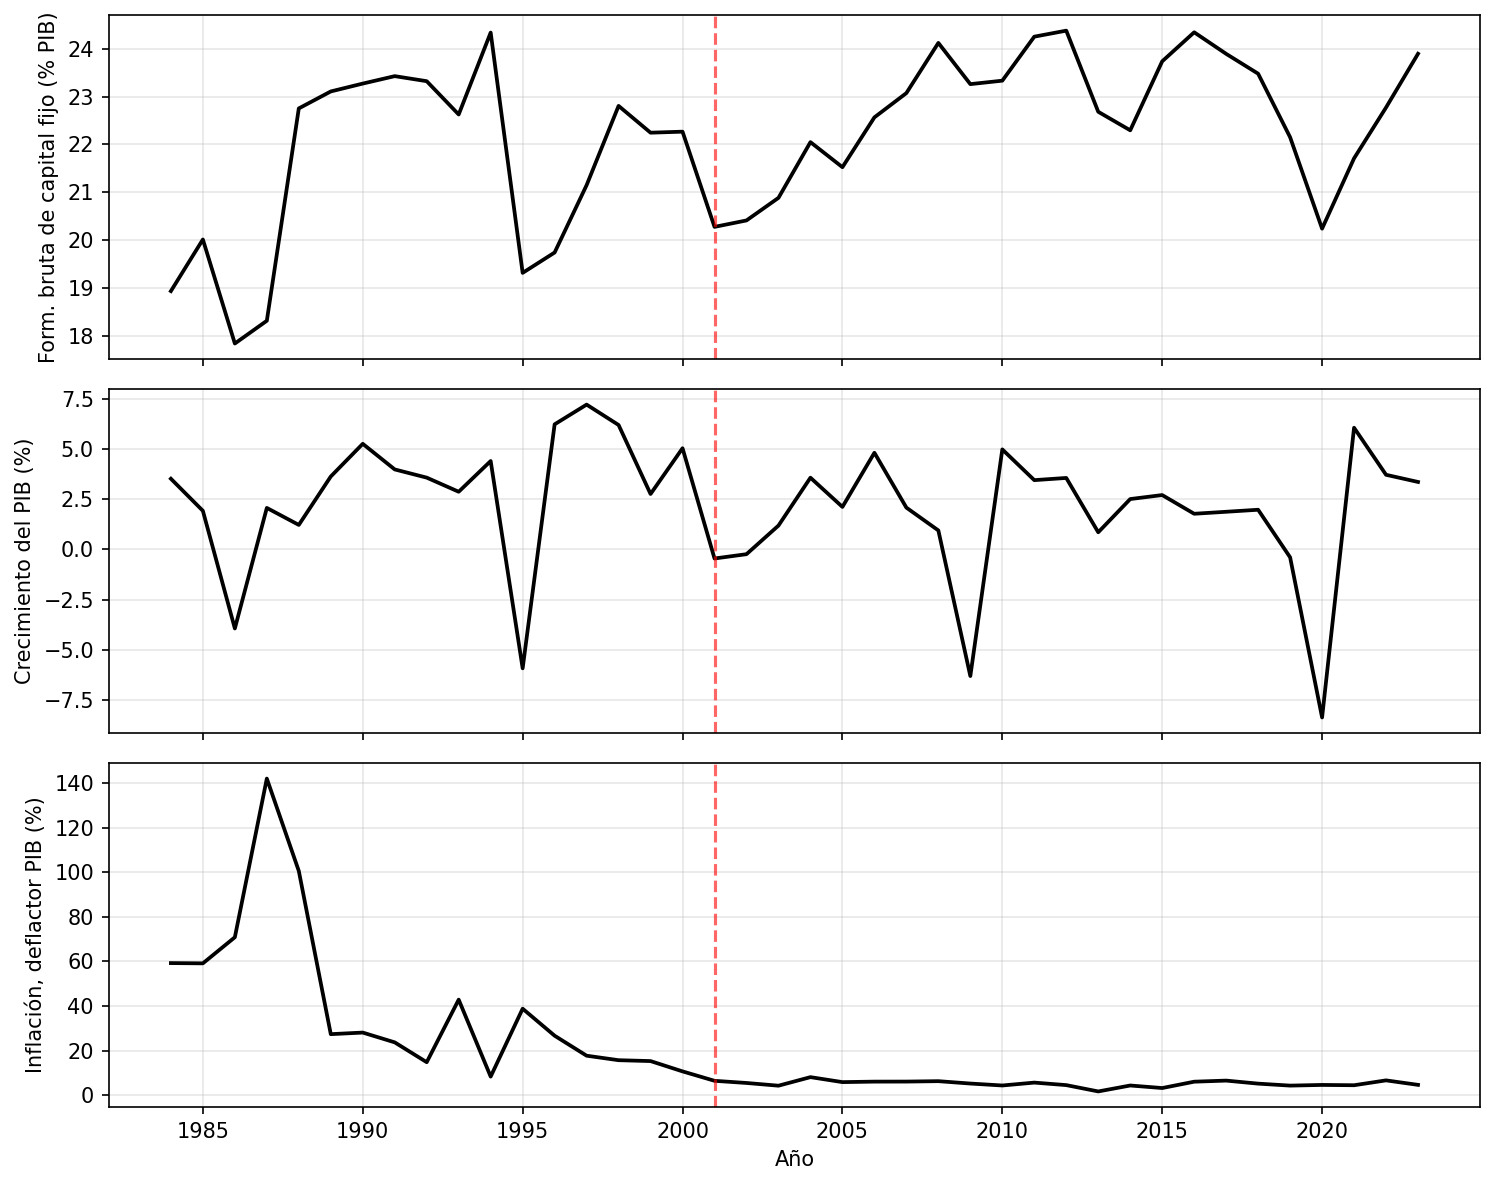

In [3]:
#| label: fig-mexico-series
#| fig-cap: "México: inversión, crecimiento e inflación (1984–2023). Línea roja: adopción del IT."
mx = df[df["country_name"] == "Mexico"].set_index("year").sort_index()

series = [
    (OUTCOME,                  "Form. bruta de capital fijo (% PIB)"),
    ("gdp_growth",             "Crecimiento del PIB (%)"),
    ("gdp_deflator_inflation", "Inflación, deflactor PIB (%)"),
]
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, (col, lab) in zip(axes, series):
    ax.plot(mx.index, mx[col], color="black", lw=1.8)
    ax.axvline(TREATMENT_YEAR, color="red", ls="--", alpha=0.6)
    ax.set_ylabel(lab); ax.grid(alpha=0.3)
axes[-1].set_xlabel("Año")
fig.tight_layout()
plt.show()

La inflación mexicana evidencia su carácter volátil: niveles de dos dígitos en los años ochenta y noventa que solo se estabilizan tras la adopción del IT. Esa volatilidad pre-2001 es justamente la razón por la que el control sintético sobre la inflación falla para México (Sección 2) y por la que elegimos la inversión como *outcome*.

Una primera lectura ingenua compararía la inversión promedio antes y después de 2001. La @tbl-prepost reporta esas medias.

In [4]:
#| label: tbl-prepost
#| tbl-cap: "Inversión media de México, pre vs post adopción del IT."
pre  = mx.loc[:TREATMENT_YEAR - 1, OUTCOME].mean()
post = mx.loc[TREATMENT_YEAR:, OUTCOME].mean()
tbl = pd.DataFrame({
    "Periodo": [f"Pre-IT (<{TREATMENT_YEAR})", f"Post-IT (≥{TREATMENT_YEAR})", "Diferencia"],
    "Inversión media (% PIB)": [round(pre, 2), round(post, 2), round(post - pre, 2)],
}).set_index("Periodo")
Markdown(tbl.to_markdown())

| Periodo         |   Inversión media (% PIB) |
|:----------------|--------------------------:|
| Pre-IT (<2001)  |                     21.5  |
| Post-IT (≥2001) |                     22.66 |
| Diferencia      |                      1.17 |

El cuadro revela una aparente paradoja: la inversión promedio fue **mayor** después de 2001 que antes. Concluir de aquí que el IT favoreció la inversión sería, sin embargo, un error de inferencia. La comparación pre/post no controla por lo que habría ocurrido con la inversión en ausencia del IT —es decir, por el contrafactual—. Factores globales como el auge de materias primas de los 2000, el ciclo de liquidez internacional o la propia recuperación tras la crisis de 1995 pudieron elevar la inversión con independencia del régimen monetario. La pregunta causal correcta no es "¿subió la inversión tras el IT?", sino "¿subió **más o menos** de lo que habría subido sin IT?". Responderla requiere construir un contrafactual creíble, que es justamente lo que provee el método de control sintético.

**Una advertencia que la descripción ya anticipa.** El contrafactual sintético será una combinación ponderada de economías no-OCDE. Conviene mirar de qué tipo de economías se trata antes de estimarlo. La @fig-commodity contrasta la trayectoria de inversión de México con la de tres exportadores de materias primas que —como veremos en la Sección 6— concentran buena parte del peso del México sintético: Mongolia, Mauritania y Bolivia.

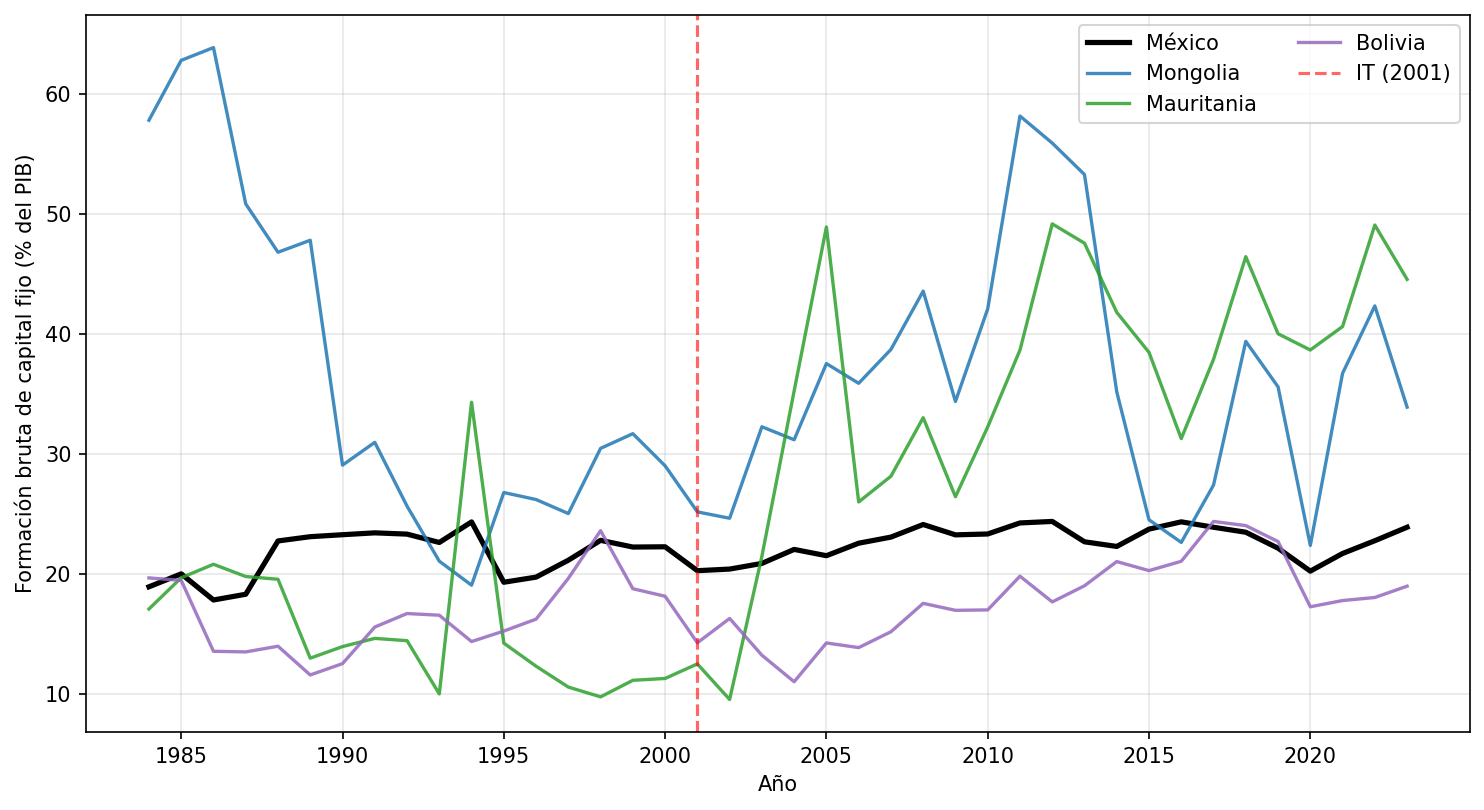

In [5]:
#| label: fig-commodity
#| fig-cap: "Inversión (% del PIB): México vs. tres donantes exportadores de materias primas que componen el sintético. Línea roja: adopción del IT (2001)."
donantes_cmd = ["Mongolia", "Mauritania", "Bolivia"]
piv = (df[df["country_name"].isin(["Mexico"] + donantes_cmd)]
       .pivot(index="year", columns="country_name", values=OUTCOME))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(piv.index, piv["Mexico"], color="black", lw=2.5, label="México")
for c, col in zip(donantes_cmd, ["#1f77b4", "#2ca02c", "#9467bd"]):
    ax.plot(piv.index, piv[c], color=col, lw=1.6, alpha=0.85, label=c)
ax.axvline(TREATMENT_YEAR, color="red", ls="--", alpha=0.6, label=f"IT ({TREATMENT_YEAR})")
ax.set_xlabel("Año"); ax.set_ylabel("Formación bruta de capital fijo (% del PIB)")
ax.grid(alpha=0.3); ax.legend(ncol=2)
fig.tight_layout()
plt.show()

El contraste es revelador. Mientras la inversión de México se mantuvo prácticamente plana entre el período pre y post-2001 (de 22.2% a 22.7% del PIB en promedio), la de Mongolia subió 9.4 puntos y la de Mauritania más de 21, impulsadas por el auge de exportaciones minerales que alimentó la demanda china de materias primas. Como el control sintético construye el "México sin IT" combinando precisamente este tipo de economías, una parte del *gap* negativo podría no reflejar un efecto del IT, sino el hecho de que los donantes vivieron un *boom* de inversión que México —economía manufacturera integrada a Estados Unidos— no compartió. La Sección 7 desarrolla esta hipótesis del *China Shock* asimétrico.

La @fig-mexico-financ muestra dos dimensiones financieras de México que la literatura vincula con la inversión: los flujos de inversión extranjera directa (IED) y la tasa de interés activa (*lending rate*).

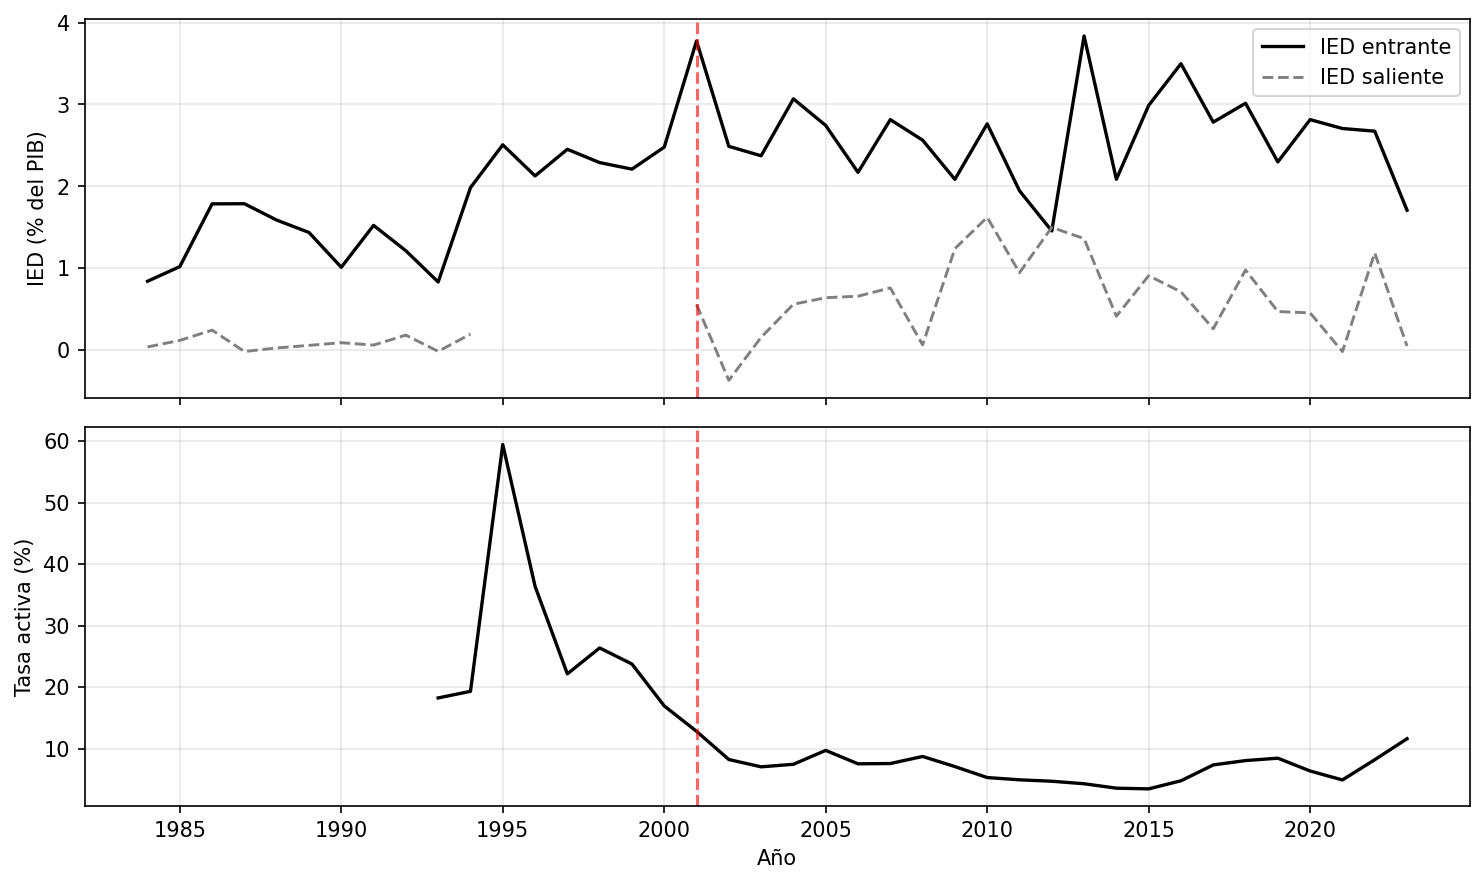

In [6]:
#| label: fig-mexico-financ
#| fig-cap: "México: flujos de IED (% del PIB) y tasa de interés activa (1984–2023). Línea roja: adopción del IT."
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(mx.index, mx["fdi_inflows"],  color="black", lw=1.6, label="IED entrante")
axes[0].plot(mx.index, mx["fdi_outflows"], color="gray",  lw=1.4, ls="--", label="IED saliente")
axes[0].set_ylabel("IED (% del PIB)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(mx.index, mx["lending_rate"], color="black", lw=1.6)
axes[1].set_ylabel("Tasa activa (%)"); axes[1].set_xlabel("Año"); axes[1].grid(alpha=0.3)
for ax in axes:
    ax.axvline(TREATMENT_YEAR, color="red", ls="--", alpha=0.6)
fig.tight_layout()
plt.show()

La tasa de interés activa cayó de niveles superiores al 40% a comienzos de los años noventa a un dígito tras la consolidación del IT —evidencia de que la estabilización de precios sí se transmitió al costo del crédito—, mientras que la IED se mantuvo como fuente relevante de financiamiento de la inversión sin un quiebre nítido en 2001. Ambas series matizan el relato de "credibilidad débil": si el canal monetario del IT hubiera fallado por completo, no esperaríamos ver esta normalización de las tasas. Volvemos sobre esta tensión en la Sección 7.

# Estrategia empírica

**El método de control sintético.** El control sintético [@abadie2003; @abadie2010] construye un contrafactual para la unidad tratada —México— como una combinación lineal ponderada de unidades de control que no recibieron el tratamiento. Los pesos $w_j \geq 0$, con $\sum_j w_j = 1$, se eligen de modo que el "México sintético" reproduzca lo mejor posible la trayectoria pre-tratamiento del *outcome* y de los predictores de la inversión. La idea intuitiva es construir un "México sin IT" a partir de países que, combinados, se parecen a México antes de 2001; el efecto del IT se estima como la diferencia (el *gap*) entre la inversión observada de México y la de su sintético después de 2001.

**Predictores y ventana.** El sintético se ajusta sobre el período pre-tratamiento 1990–2000 usando como predictores las cuatro covariables descritas en la Sección 3 más los once rezagos anuales del *outcome*. La ventana inicia en 1990 —y no en 1984— porque la crisis de la deuda de los años ochenta introduce valores faltantes y un ajuste pre-tratamiento notablemente peor; la Sección 6 documenta esta decisión como verificación de robustez.

**Justificación del *donor pool* no-OCDE.** Restringimos el conjunto de donantes a economías que no eran miembros de la OCDE durante el período pre-tratamiento. La razón es metodológica: con el *donor pool* completo, economías avanzadas —en particular Estados Unidos— pueden recibir pesos elevados y dominar el contrafactual, pese a no ser comparables estructuralmente con México. Restringir a no-OCDE produce un sintético compuesto por economías de ingreso medio y bajo, más comparables. Esta es una decisión propia, en el espíritu de la estratificación que @mccloud2022 explora en su análisis de robustez; conviene recordar (Sección 2) que en McCloud el comparador con buen ajuste para México es su submuestra de países *en desarrollo* —no la de no-OCDE—, porque en su clasificación México figura como miembro de la OCDE.

**Inferencia por placebos in-space.** Como el control sintético se aplica a una sola unidad tratada, los errores estándar convencionales no son apropiados [@adhikari2022]. La inferencia se realiza mediante placebos *in-space* [@firpo2018]: se reasigna falsamente el tratamiento a cada país del *donor pool* y se estima su *gap* placebo. Si el efecto estimado para México es grande en relación con la distribución de los efectos placebo, se interpreta como evidencia de un efecto genuino. El pseudo *p-value* es la proporción de placebos cuyo efecto iguala o supera (en magnitud) al de México. Siguiendo la regla de @adhikari2022, un pseudo *p-value* superior a 0.10 indica que **no** hay evidencia estadísticamente significativa de un efecto al nivel convencional. Adhikari advierte, además, que con un *donor pool* pequeño la potencia de esta inferencia es limitada —una salvedad pertinente para nuestra interpretación (Sección 7).

**Supuestos del SCM y su plausibilidad en este contexto.** Antes de estimar, conviene hacer explícitos los supuestos de los que depende la interpretación causal del *gap*, y adelantar por qué cada uno es frágil en el caso de México en 2001 (la Sección 7 los desarrolla con evidencia):

1. **Invarianza paramétrica.** Las ponderaciones estimadas sobre 1990–2000 deben seguir describiendo la relación México–donantes después de 2001. Si el IT alteró la formación de expectativas, este supuesto se debilita (Crítica de Lucas, §2.5) —aunque la evidencia de @rudebusch2005 sugiere que el sesgo podría ser menor de lo temido.
2. **No interferencia (SUTVA).** El tratamiento de México no debe afectar a los donantes. Es inviable en macro global: la Fed, la crisis de 2008 y el ciclo de *commodities* afectan a todas las unidades simultáneamente y de forma asimétrica.
3. **Ausencia de choques coincidentes no controlados.** El *gap* solo identifica el efecto del IT si ningún otro cambio estructural coincide con 2001. El *China Shock* —que se acelera justamente con el ingreso de China a la OMC en diciembre de 2001— viola directamente este supuesto.
4. **Ajuste pre-tratamiento como condición necesaria, no suficiente.** Un RMSPE bajo es requisito mínimo de comparabilidad, pero no descarta el sobreajuste ni valida el contrafactual post-tratamiento.

Estos supuestos no se cumplen de forma evidente en nuestro caso; por ello la lectura de los resultados será cautelosa y la Sección 7 está dedicada a evaluarlos.

**Implementación.** Todo el cómputo se ejecuta de forma autocontenida en este documento con la librería `pysyncon` (optimización Nelder-Mead), a partir del CSV congelado y sin acceder a la API del Banco Mundial. Las tres funciones siguientes implementan, respectivamente, la construcción de la muestra (filtro de datos completos y *donor pool* no-OCDE), el ajuste del control sintético y el cálculo del *gap*. El test de placebos —costoso (≈80 estimaciones)— se precomputa con `script/_run_placebos.py`, que cachea la figura y el pseudo *p-value* en `out/`.

In [7]:
#| label: funciones-scm
def build_sample(df, predictors, pre_start, pre_end=PRE_END):
    """Filtra países con datos completos en el pre-tratamiento y arma el donor pool no-OCDE."""
    pre = df[(df["year"] >= pre_start) & (df["year"] <= pre_end)]
    needed = predictors + [OUTCOME]
    missing = pre.groupby("country_name")[needed].apply(lambda x: x.isnull().sum().sum())
    complete = missing[missing == 0].index.tolist()

    treated    = [c for c in complete if c in IT_ADOPTERS]
    donors_all = [c for c in complete if c not in IT_ADOPTERS]
    # Membresía OCDE histórica: donante válido solo si NO fue OCDE en el pre-tratamiento
    non_oecd = pre.groupby("country_name")["oecd_member"].max()
    non_oecd = non_oecd[non_oecd == 0].index.tolist()
    donor_pool = [c for c in donors_all if c in non_oecd]

    sample = treated + donor_pool
    df_f = (df[df["country_name"].isin(sample)]
            .sort_values(["country_name", "year"]).reset_index(drop=True))
    return df_f, treated, donor_pool


def fit_synth(df_f, donor_pool, predictors, pre_start):
    """Ajusta el control sintético de México (predictores + rezagos anuales del outcome)."""
    special = [(OUTCOME, [yr], "mean") for yr in range(pre_start, TREATMENT_YEAR)]
    dataprep = Dataprep(
        foo=df_f, predictors=predictors, predictors_op="mean",
        special_predictors=special, dependent=OUTCOME,
        unit_variable="country_name", time_variable="year",
        treatment_identifier="Mexico",
        controls_identifier=[c for c in donor_pool if c != "Mexico"],
        time_predictors_prior=range(pre_start, TREATMENT_YEAR),
        time_optimize_ssr=range(pre_start, TREATMENT_YEAR),
    )
    synth = Synth()
    synth.fit(dataprep=dataprep, optim_method="Nelder-Mead")
    return dataprep, synth


def treatment_gap(synth, pre_start):
    """Devuelve (observado, sintético, gap) sobre todo el período disponible."""
    end = int(synth.dataprep.foo["year"].max()) + 1
    Z0, Z1 = synth.dataprep.make_outcome_mats(time_period=range(pre_start, end))
    synthetic = synth._synthetic(Z0=Z0)
    return Z1, synthetic, Z1 - synthetic

# Resultados

In [8]:
#| label: estimacion-base
df_f, treated, donor_pool = build_sample(df, PREDICTORS, PRE_START)
dataprep, synth = fit_synth(df_f, donor_pool, PREDICTORS, PRE_START)

weights = synth.weights(round=3, threshold=0.001)
rmspe   = float(np.sqrt(synth.mspe()))
Z1, synthetic, gap = treatment_gap(synth, PRE_START)

print(f"Tratados (IT): {len(treated)} | Donantes no-OCDE: {len(donor_pool)} "
      f"| Muestra: {len(treated) + len(donor_pool)} | RMSPE pre: {rmspe:.4f}")

Tratados (IT): 25 | Donantes no-OCDE: 83 | Muestra: 108 | RMSPE pre: 0.1074


**El México sintético.** El control sintético de México se compone de 15 economías no-OCDE con peso positivo (@tbl-weights). El ajuste pre-tratamiento es excelente: la raíz del error cuadrático medio de predicción (RMSPE) es 0.1074, comparable al 0.11–0.12 que @mccloud2022 reporta para México en su muestra de buen ajuste.

In [9]:
#| label: tbl-weights
#| tbl-cap: "Composición del México sintético (pesos > 0.001), especificación non-OECD."
w = weights[weights > 0.001].sort_values(ascending=False).rename("Peso").to_frame()
w.index.name = "País donante"
Markdown(w.to_markdown())

| País donante   |   Peso |
|:---------------|-------:|
| Mongolia       |  0.179 |
| Mauritius      |  0.157 |
| Bolivia        |  0.129 |
| Madagascar     |  0.109 |
| Mauritania     |  0.097 |
| Senegal        |  0.087 |
| Honduras       |  0.062 |
| Botswana       |  0.049 |
| Chad           |  0.036 |
| Sudan          |  0.025 |
| Bangladesh     |  0.023 |
| Bahamas, The   |  0.02  |
| Guinea-Bissau  |  0.017 |
| Tanzania       |  0.006 |
| Kuwait         |  0.005 |

**Trayectoria observada vs contrafactual.** La @fig-path muestra la inversión observada de México frente a la de su sintético. Ambas trayectorias se superponen estrechamente antes de 2001 (reflejo del buen ajuste) y se separan después: la inversión observada queda sistemáticamente **por debajo** de la del contrafactual.

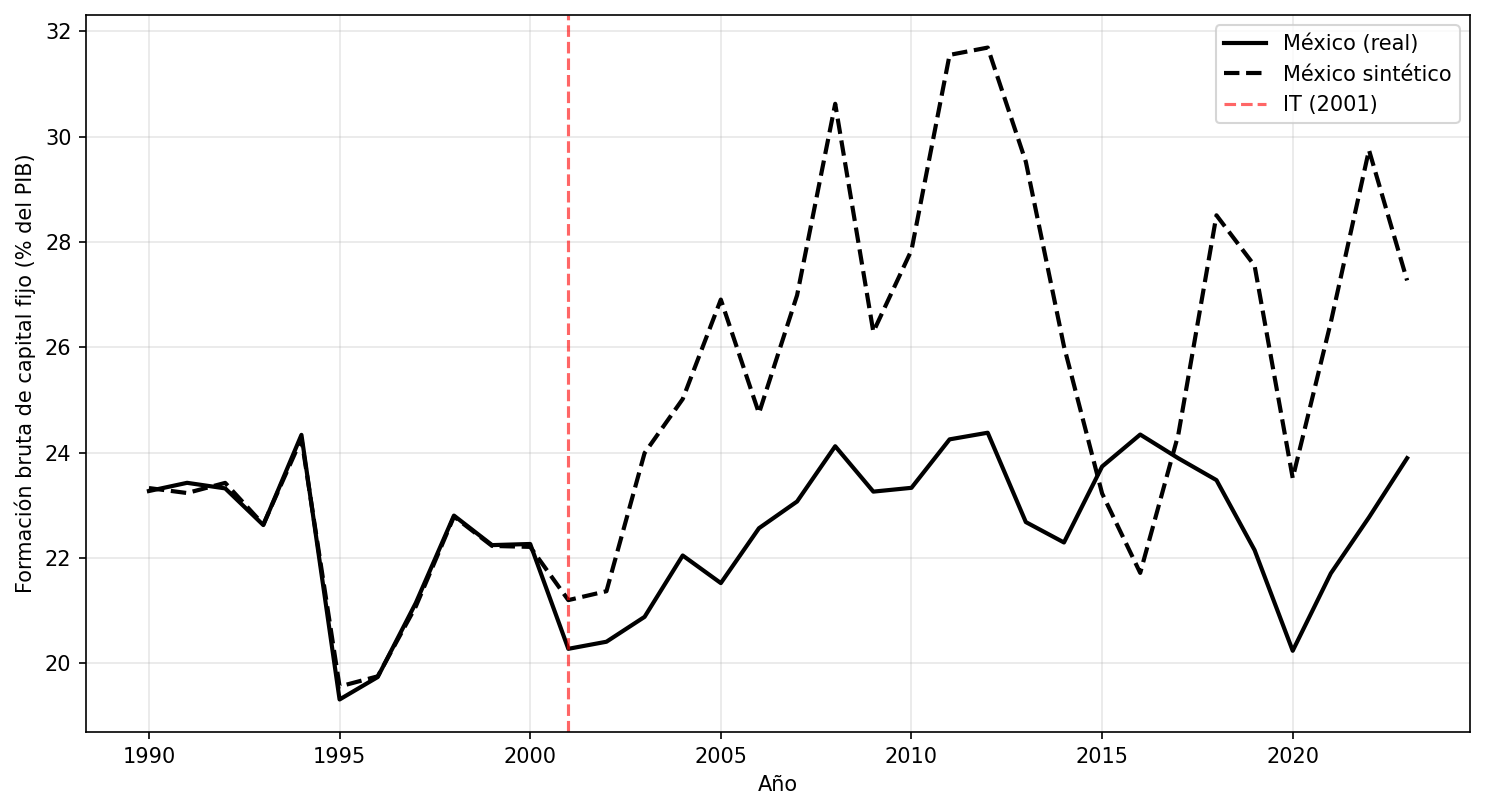

In [10]:
#| label: fig-path
#| fig-cap: "México observado vs México sintético: formación bruta de capital fijo."
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(Z1.index, Z1.values, color="black", lw=2, label="México (real)")
ax.plot(synthetic.index, synthetic.values, color="black", lw=2, ls="--", label="México sintético")
ax.axvline(TREATMENT_YEAR, color="red", ls="--", alpha=0.6, label=f"IT ({TREATMENT_YEAR})")
ax.set_xlabel("Año"); ax.set_ylabel("Formación bruta de capital fijo (% del PIB)")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

La @fig-gap traduce esa separación en el efecto estimado año a año (el *gap*: México observado menos sintético).

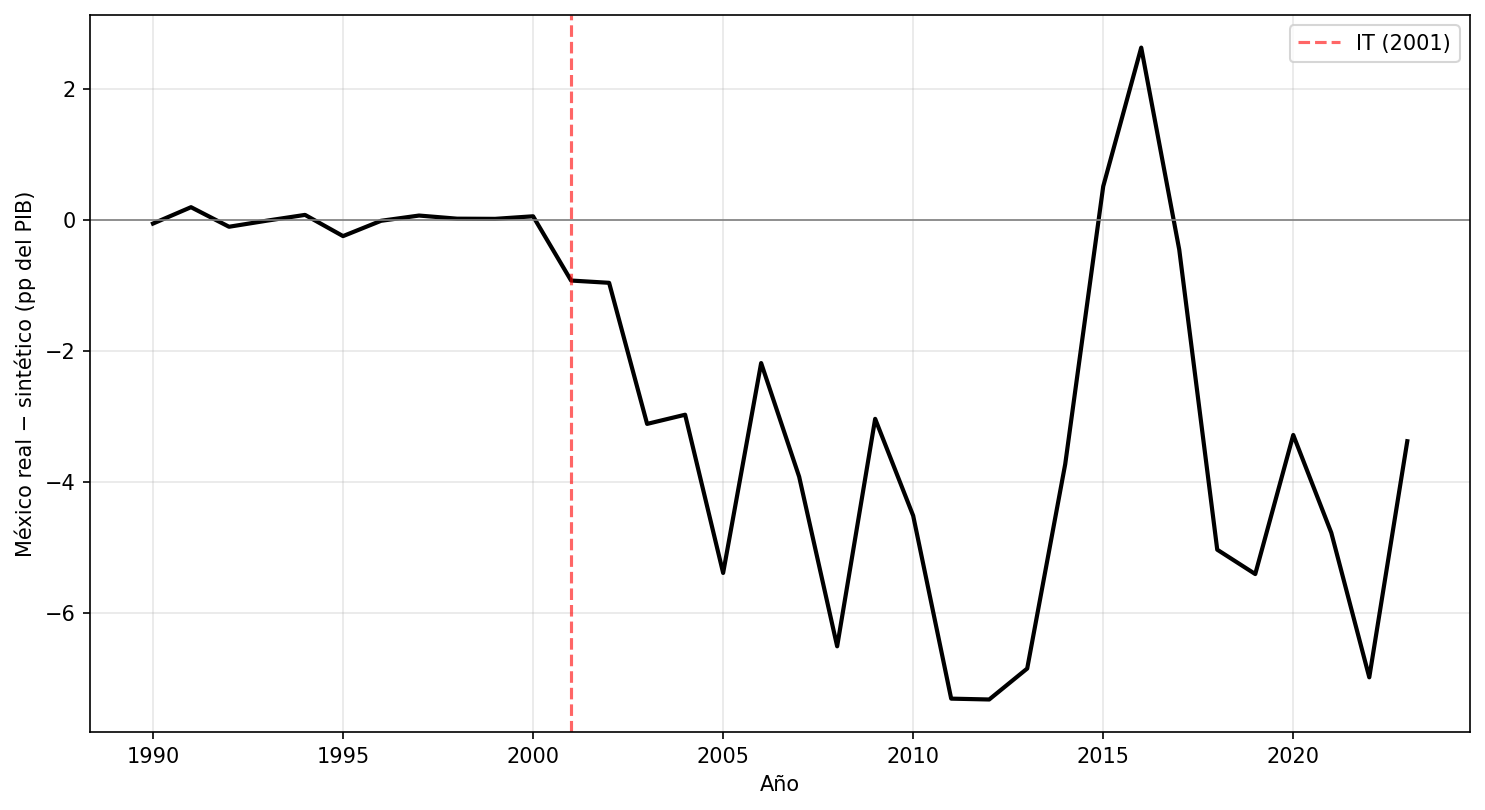

In [11]:
#| label: fig-gap
#| fig-cap: "Efecto estimado del IT sobre la inversión en México (gap, pp del PIB)."
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(gap.index, gap.values, color="black", lw=2)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(TREATMENT_YEAR, color="red", ls="--", alpha=0.6, label=f"IT ({TREATMENT_YEAR})")
ax.set_xlabel("Año"); ax.set_ylabel("México real − sintético (pp del PIB)")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

El *gap* es persistentemente negativo durante todo el período post-2001, con un promedio cercano a $-3.7$ pp del PIB y un mínimo en torno a $-7.3$ pp hacia 2011–2012. La @tbl-effects compara nuestros efectos estimados con los de @mccloud2022 en años clave: la dirección coincide y las magnitudes son del mismo orden, con diferencias atribuibles a la actualización de datos y a la especificación non-OECD.

In [12]:
#| label: tbl-effects
#| tbl-cap: "Efecto estimado del IT sobre la inversión en México vs McCloud (2022), años clave."
MCCLOUD = {2004: -3.21, 2005: -3.54, 2007: -4.79, 2008: -7.48, 2011: -6.25}
rows = [{"Año": y,
         "Estimado (pp)": round(float(gap.loc[y]), 2),
         "McCloud (pp)": m,
         "Diferencia": round(float(gap.loc[y]) - m, 2)}
        for y, m in MCCLOUD.items() if y in gap.index]
Markdown(pd.DataFrame(rows).set_index("Año").to_markdown())

|   Año |   Estimado (pp) |   McCloud (pp) |   Diferencia |
|------:|----------------:|---------------:|-------------:|
|  2004 |           -2.97 |          -3.21 |         0.24 |
|  2005 |           -5.38 |          -3.54 |        -1.84 |
|  2007 |           -3.92 |          -4.79 |         0.87 |
|  2008 |           -6.5  |          -7.48 |         0.98 |
|  2011 |           -7.3  |          -6.25 |        -1.05 |

**Inferencia por placebos.** La @fig-placebos contrasta el *gap* de México (línea roja) con los *gaps* placebo de los donantes no-OCDE. Por su costo (≈80 estimaciones SCM), el test se precomputa con `script/_run_placebos.py` y se cachea en `out/`; el bloque siguiente lee esa caché.

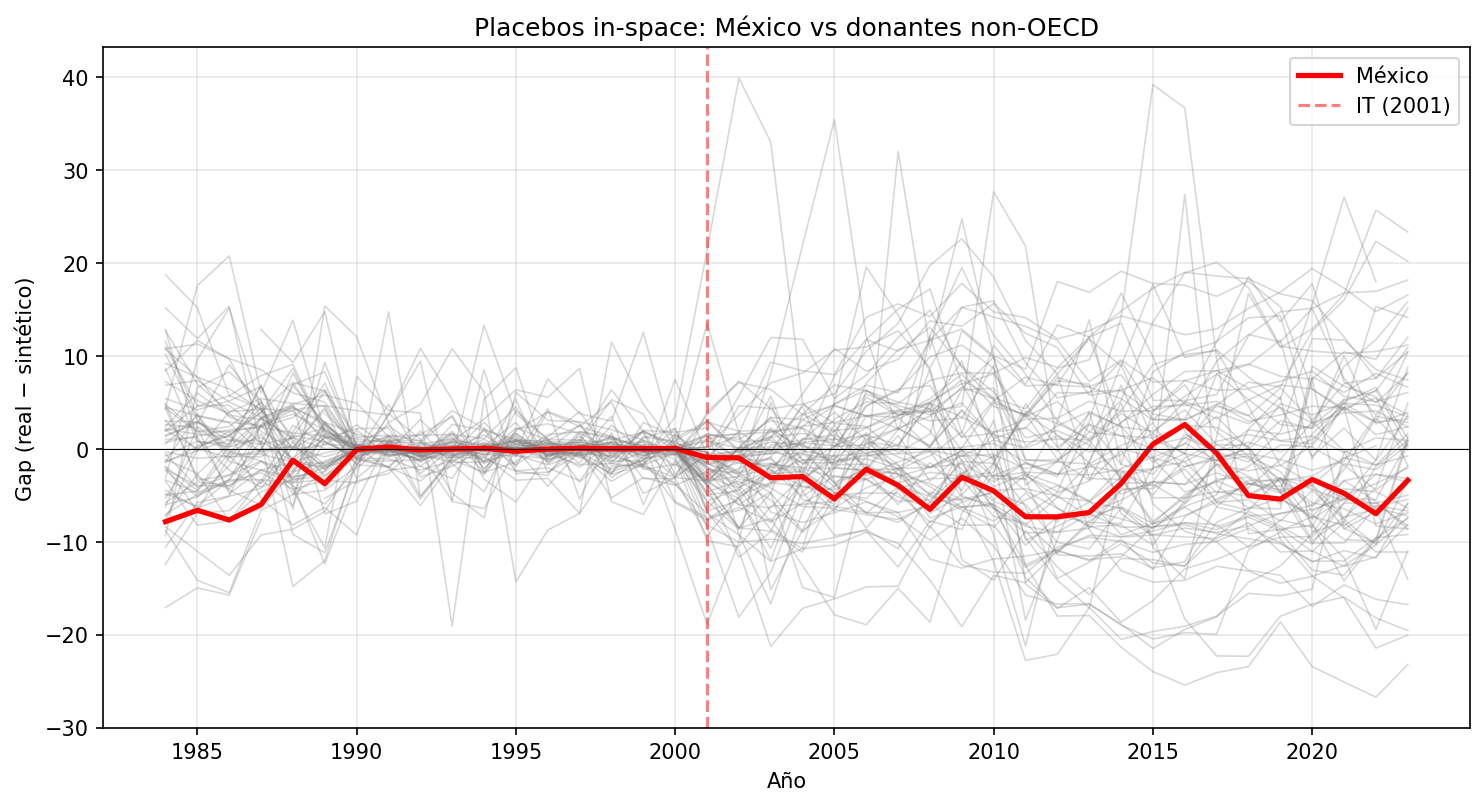

In [13]:
#| label: fig-placebos
#| fig-cap: "Placebos in-space: gap de México vs gaps de los donantes non-OECD."
out_dir   = Path("out")
fig_file  = out_dir / "mexico_placebo_tests.png"
pval_file = out_dir / "placebo_pvalue.txt"

if not (fig_file.exists() and pval_file.exists()):
    raise FileNotFoundError(
        "Falta la caché de placebos. Genérala con:\n"
        "  python script/_run_placebos.py chunk 0 4   (y 1 4, 2 4, 3 4)\n"
        "  python script/_run_placebos.py combine 4")

placebo_pvalue = float(pval_file.read_text().strip())
Image(filename=str(fig_file))

El pseudo *p-value* de México es 0.75. Conviene leer este número con precisión, porque es el corazón de la inferencia del método. Un pseudo *p-value* de 0.75 significa que **el 75% de los países del *donor pool* —economías que nunca adoptaron IT— exhiben un *gap* igual o más extremo que el de México** al reasignarles falsamente el tratamiento. Dicho de otro modo, el "efecto" estimado para México cae de lleno dentro de la nube de efectos placebo: es indistinguible de lo que el propio sistema macroeconómico global genera por azar. En el marco del control sintético, donde el pseudo *p-value* **es** la prueba de relevancia [@adhikari2022], esto no debe leerse como un resultado "económicamente relevante pero estadísticamente no concluyente" —una formulación que confundiría la magnitud del *gap* con su significancia—. La lectura honesta es que la inferencia **no respalda** la existencia de un efecto distinguible del ruido. La magnitud del *gap* (−3.7 pp en promedio) es real como descripción, pero no autoriza una interpretación causal. La Sección 7 examina por qué un *gap* tan grande convive con una inferencia tan débil, y qué nos dice eso sobre la pregunta y el método.

**Robustez.** La @tbl-robust compara la especificación base con dos alternativas: (i) incluir el ahorro bruto como predictor y (ii) extender la ventana pre-tratamiento a 1984–2000. Reutilizamos la estimación base ya calculada y solo ajustamos las dos variantes.

In [14]:
#| label: tbl-robust
#| tbl-cap: "Verificaciones de robustez: ajuste y efecto en 2008 por especificación."
PREDICTORS_SAV = PREDICTORS + ["gross_savings"]
variantes = [
    ("Base (non-OECD, 1990–2000)", PREDICTORS,     1990),
    ("+ ahorro bruto",             PREDICTORS_SAV, 1990),
    ("Ventana 1984–2000",          PREDICTORS,     1984),
]
rows = []
for nombre, preds, ps in variantes:
    if nombre.startswith("Base"):                 # reusar la base (no recalcular)
        dpool, rm, g = donor_pool, rmspe, gap
    else:
        d_f, _, dpool = build_sample(df, preds, ps)
        _, sy = fit_synth(d_f, dpool, preds, ps)
        rm = float(np.sqrt(sy.mspe()))
        _, _, g = treatment_gap(sy, ps)
    rows.append({"Especificación": nombre, "Donantes": len(dpool),
                 "RMSPE pre": round(rm, 4),
                 "Gap 2008 (pp)": round(float(g.loc[2008]), 2)})
Markdown(pd.DataFrame(rows).set_index("Especificación").to_markdown())

| Especificación             |   Donantes |   RMSPE pre |   Gap 2008 (pp) |
|:---------------------------|-----------:|------------:|----------------:|
| Base (non-OECD, 1990–2000) |         83 |      0.1074 |           -6.5  |
| + ahorro bruto             |         56 |      0.2707 |           -4.75 |
| Ventana 1984–2000          |         74 |      0.2895 |           -4.75 |

Ambas alternativas deterioran el ajuste pre-tratamiento (RMSPE mayor) sin alterar la conclusión cualitativa: el efecto estimado sigue siendo negativo. La especificación base —sin ahorro y con ventana 1990–2000— es la de mejor ajuste y la que adoptamos como principal.

# Discusión

El control sintético produjo un *gap* negativo, grande y persistente, pero una inferencia que no lo distingue del ruido. Esta sección argumenta que la lectura honesta de esa combinación no es "el IT redujo la inversión, aunque no podamos probarlo", sino algo más fundamental: **en este caso, el control sintético no puede aislar el efecto del IT**, porque la adopción del régimen coincidió con choques estructurales que el método no controla y porque sus supuestos de identificación (§2.5) son frágiles aquí. Examinamos las cuatro fuentes de esa fragilidad en orden de solidez de la evidencia, sin inflar ninguna.

## Una historia de dos lecturas

El análisis descriptivo (Sección 4) mostraba que la inversión promedio de México fue mayor después de 2001 que antes. El control sintético invierte esa lectura: frente al contrafactual, la inversión observada queda persistentemente por debajo. Es tentador concluir que el método "corrige" la lectura ingenua y revela el verdadero efecto del IT. Pero esa conclusión presupone que el contrafactual es válido —es decir, que el "México sintético" representa fielmente lo que México habría hecho sin IT y *con todo lo demás igual*. El resto de la sección cuestiona precisamente ese "todo lo demás igual".

## El *China Shock* asimétrico: ¿política monetaria o comercio global?

Este es, a nuestro juicio, el problema de identificación más serio. La adopción formal del IT (2001) coincide con la aceleración del *China Shock*: el ingreso de China a la OMC en diciembre de 2001 consolidó su expansión exportadora [@autor2016]. El choque fue **marcadamente asimétrico**. China compitió en manufacturas, desplazando a economías como México —integrada al mercado estadounidense vía TLCAN— y comprimiendo la rentabilidad y la inversión en su sector manufacturero [@tradeintensity2023; @cfr2025mexico]. En paralelo, su voraz demanda de materias primas generó un súper-ciclo de *commodities* que **benefició** a los países exportadores de recursos.

Aquí la composición del sintético deja de ser un detalle técnico y se vuelve decisiva. Como muestra la @tbl-weights, el "México sintético" se compone mayoritariamente de exportadores de materias primas: Mongolia (peso 0.18), Bolivia (0.13), Mauritania (0.10), más Botswana, Chad, Sudán y Kuwait. La @fig-commodity ya anticipó el problema: la inversión de estos donantes se disparó tras 2001 (Mongolia +9.4 pp, Mauritania +21 pp) mientras la de México se mantuvo plana. El algoritmo construye así un contrafactual que "habría invertido mucho más" no por ausencia de IT, sino porque sus componentes cabalgaron un *boom* de *commodities* que México, por su estructura productiva, no podía compartir. El *gap* negativo capta, en una proporción imposible de cuantificar con esta especificación, el **diferencial de exposición al *China Shock***, no el efecto del régimen monetario. Es una violación directa del supuesto de ausencia de choques coincidentes (§2.5) y, dado que el choque golpea de forma desigual a tratada y controles, también del supuesto SUTVA.

## ¿Es válido el contrafactual? La Crítica de Lucas, matizada

Un segundo problema es más sutil y su evidencia, más ambigua. La Crítica de Lucas [@lucas1976] sugiere que el cambio de régimen monetario pudo alterar la estructura de la economía mexicana, invalidando las ponderaciones estimadas con datos pre-2001. Sin embargo, no conviene sobrecargar este argumento. @rudebusch2005 encuentra que las representaciones autorregresivas de modelos de política monetaria son sorprendentemente estables ante cambios de regla, lo que **debilita** la versión fuerte de la objeción. La evidencia institucional mexicana apunta, además, en una dirección que matiza el relato de "credibilidad débil": el Banco de México transitó hacia reglas prospectivas de tipo Taylor [@ramosfrancia2005] y las expectativas de inflación de largo plazo terminaron ancladas cerca de la meta del 3%, con una prima de riesgo inflacionario comprimida [@beauregard2021]. En suma, la Crítica de Lucas introduce una duda legítima sobre la extrapolación del contrafactual, pero la evidencia no permite elevarla a refutación. La tratamos como una tensión metodológica no zanjada, no como un veredicto.

## Determinantes omitidos de la inversión

¿Y si la inversión mexicana se rezagó por razones ajenas tanto al IT como a China? La literatura sobre los determinantes de la inversión en México ofrece una pista incómoda para la interpretación causal del *gap*. @cruzbrid2018, estimando modelos de rezagos distribuidos para 1988–2015, encuentran que los determinantes robustos de la inversión privada son el PIB, el gasto público y la propia inversión rezagada —y que **la tasa de interés no resulta estadísticamente significativa**; el esquema de IT ni siquiera figura entre las variables relevantes. Conviene ser honestos sobre el alcance de este argumento: el efecto neto del gasto público que estiman es un *crowding-out* pequeño (−0.15 pp), no el *crowding-in* que a veces se invoca, y la caída más pronunciada de la inversión pública es anterior a 2001. El punto, por tanto, no es que la austeridad fiscal "explique" el *gap*, sino algo más modesto y más sólido: en la mejor evidencia disponible para México, **la política monetaria no aparece como determinante de la inversión**, lo que resta verosimilitud a una interpretación que atribuye al régimen monetario un efecto de varios puntos del PIB.

## SUTVA, sobreajuste e inferencia

Aun dejando de lado lo anterior, la inferencia no sostiene la conclusión causal. Tres elementos convergen. Primero, los **spillovers globales**: la Fed, la crisis financiera de 2008–2009 y el ciclo de *commodities* —e incluso China, que figura en el propio *donor pool*— afectan a México y a sus controles de forma simultánea y heterogénea, violando SUTVA y sesgando la estimación [@abadie2021; @scmspillovers2025]. Segundo, el **sobreajuste**: lograr un RMSPE de 0.1074 sobre una ventana que incluye la crisis del Tequila, combinando economías tan disímiles como Mongolia, Mauricio o Bolivia, es más compatible con un ajuste al ruido que con una comparabilidad estructural genuina [@abadie2021]. Tercero, la **inferencia misma**: el pseudo *p-value* de 0.75 (Sección 6) indica que el *gap* de México es indistinguible del de tres cuartas partes de los placebos. La comparación con @mccloud2022 ilumina la fragilidad: él reporta un pseudo *p-value* de 0.08–0.09 con datos hasta 2017, mientras que nuestra ventana extendida a 2023 lo lleva a 0.75. Que la conclusión inferencial cambie tan drásticamente con once años adicionales de datos —y con una recomposición del *donor pool*— es, en sí mismo, señal de que la inferencia no es robusta, tal como advierte @adhikari2022 para *donor pools* pequeños y heterogéneos.

## Síntesis: qué puede y qué no puede decirnos el SCM aquí

Nuestros resultados coinciden con @mccloud2022 en la **dirección** y el **orden de magnitud** del *gap*, lo que confirma que el hallazgo descriptivo es robusto a la ventana y a la composición del *donor pool*. Pero coincidir en el *gap* no equivale a coincidir en su **interpretación**. El control sintético es una herramienta poderosa cuando el tratamiento es el único cambio estructural relevante en el entorno de la unidad tratada. México en 2001 no cumple esa condición: el IT se adoptó en el mismo año en que se aceleró un choque comercial global de signo asimétrico, sobre una economía cuya trayectoria macroeconómica la literatura ya señalaba como difícil de modelar (Sección 2). En ese escenario, el *gap* sintético es una magnitud bien definida pero de interpretación ambigua: mezcla el efecto del IT —si lo hubo— con el diferencial de exposición al *China Shock*, y la inferencia por placebos no permite separar la señal del ruido. La contribución de este ejercicio no es, por tanto, una estimación causal del efecto del IT, sino una ilustración concreta de los límites del control sintético para evaluar regímenes monetarios en presencia de choques globales coincidentes.

# Conclusiones

Este trabajo se propuso estimar el efecto causal de la adopción del *Inflation Targeting* en 2001 sobre la inversión doméstica en México, mediante el método de control sintético aplicado a un panel del Banco Mundial para 1984–2023. El control sintético arroja un *gap* **persistentemente negativo** —del orden de $-3.7$ pp del PIB en promedio, con un mínimo cercano a $-7$ pp— cuya dirección y magnitud coinciden con @mccloud2022. Nuestra conclusión, sin embargo, no es que el IT haya reducido la inversión, sino que **el método, en este caso, no permite afirmarlo**.

**Veredicto sobre la hipótesis.** No podemos rechazar **H0**: el pseudo *p-value* de la inferencia por placebos (≈0.75) indica que el efecto estimado para México es indistinguible del de tres cuartas partes de economías que nunca adoptaron IT [@adhikari2022]. Pero tampoco interpretamos esto como confirmación de un efecto negativo "no detectado": el *gap* está confundido con un choque coincidente —el *China Shock* asimétrico, que benefició a los exportadores de materias primas que componen el contrafactual y perjudicó a la manufactura mexicana— y con supuestos de identificación frágiles en un entorno macroeconómico de fuertes *spillovers*. La evidencia no es congruente con H1 *ni* con su negación: simplemente, el control sintético no separa el efecto del IT de los demás cambios estructurales que coincidieron con 2001.

**Sobre el método.** El valor de este ejercicio es, paradójicamente, lo que revela sobre sus propios límites. El control sintético es fiable cuando el tratamiento es el único cambio estructural relevante en el entorno de la unidad tratada; aplicarlo a la adopción de un régimen monetario que coincide con un choque comercial global, sobre una economía cuya trayectoria la literatura ya señalaba como difícil de modelar, produce un número preciso pero de interpretación ambigua. Es una ilustración concreta de la advertencia de @abadie2021 sobre las condiciones de validez del método.

**Sobre México.** La evidencia institucional disponible —tasas activas que cayeron de más del 40% a un dígito (Sección 4), expectativas de inflación ancladas cerca de la meta y una prima de riesgo comprimida [@beauregard2021], y la transición a reglas de política prospectivas [@ramosfrancia2005]— sugiere que el IT fue, en balance, una política de estabilización razonablemente exitosa. Si la inversión mexicana se rezagó respecto de otras economías emergentes, la evidencia de @cruzbrid2018 —donde la política monetaria no figura entre los determinantes de la inversión— no apunta al IT como causa.

**Limitaciones.** (i) El control sintético mide efectos reducidos, no mecanismos. (ii) El pseudo *p-value* elevado y su sensibilidad a la ventana temporal limitan severamente la inferencia. (iii) No aislamos los choques contemporáneos —el *China Shock*, el TLCAN (1994), la crisis financiera de 2008— que la especificación no controla y que contaminan el *gap*. (iv) El *donor pool* no-OCDE, aunque más comparable que la muestra completa, está dominado por exportadores de materias primas estructuralmente distintos de México.

**Extensiones.** Trabajo futuro podría: incorporar controles explícitos de exposición comercial a China (por ejemplo, la participación de manufacturas en exportaciones o índices de competencia importadora) para descontar el *China Shock*; aplicar el *Augmented Synthetic Control* [@benmichael2021] u otros estimadores con sesgo corregido; modelar los *spillovers* de forma explícita [@scmspillovers2025]; y comparar a México con otros adoptantes latinoamericanos (Chile, Colombia, Brasil, Perú) para distinguir lo idiosincrásico de lo común. La lección de fondo, no obstante, es anterior a la elección del estimador: ninguna herramienta econométrica puede aislar el efecto de una política cuando esta coincide con una constelación de choques estructurales de escala global.

# Referencias {.unnumbered}

::: {#refs}
:::